<a href="https://colab.research.google.com/github/charvi02/AI_Heart-Disease-Prediction/blob/main/task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

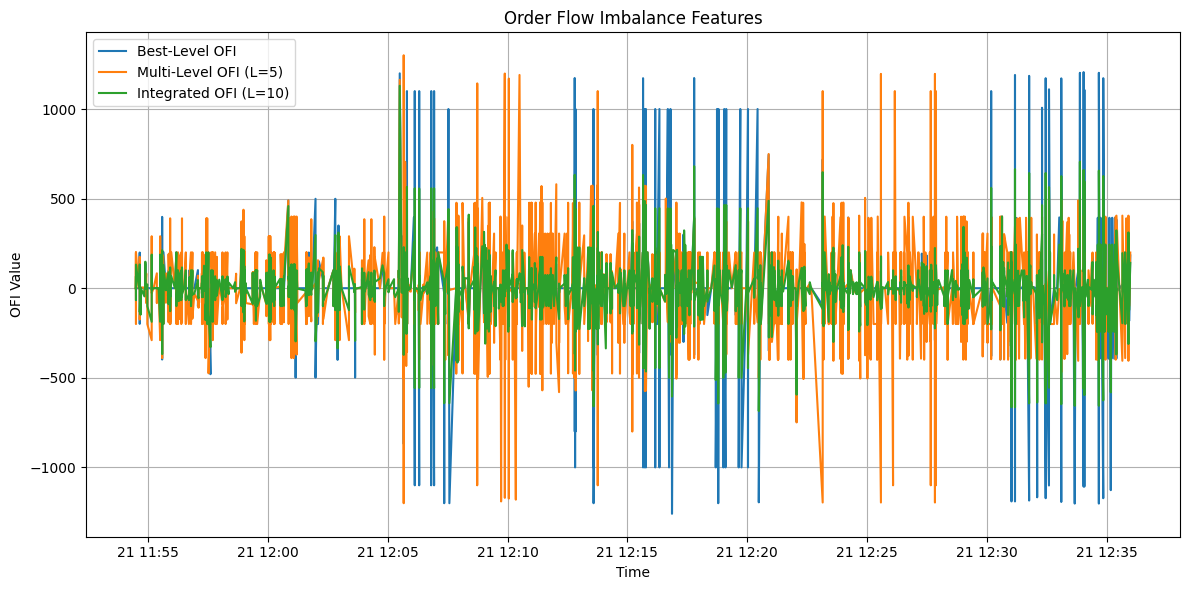

In [2]:

import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("first_25000_rows.csv")
df['ts_event'] = pd.to_datetime(df['ts_event'])
df.sort_values('ts_event', inplace=True)
df.reset_index(drop=True, inplace=True)


def compute_ofi_features(df, levels=5, integrated_levels=10):
    df = df.copy()
    ofi_df = pd.DataFrame()
    ofi_df['timestamp'] = df['ts_event']

    # Best-Level OFI (Level 0)
    ofi_df['best_ofi'] = df['bid_sz_00'].diff().fillna(0) - df['ask_sz_00'].diff().fillna(0)

    # Multi-Level OFI
    multi_ofi = 0
    for level in range(levels):
        bid_col = f'bid_sz_0{level}'
        ask_col = f'ask_sz_0{level}'
        multi_ofi += df[bid_col].diff().fillna(0) - df[ask_col].diff().fillna(0)
    ofi_df[f'multi_ofi_L{levels}'] = multi_ofi

    # Integrated OFI (weighted)
    int_ofi = 0
    for level in range(integrated_levels):
        bid_col = f'bid_sz_0{level}'
        ask_col = f'ask_sz_0{level}'
        weight = 1 / (level + 1)
        int_ofi += weight * (df[bid_col].diff().fillna(0) - df[ask_col].diff().fillna(0))
    ofi_df['integrated_ofi'] = int_ofi

    return ofi_df


ofi_df = compute_ofi_features(df, levels=5, integrated_levels=10)


ofi_df.head()


plt.figure(figsize=(12, 6))
plt.plot(ofi_df['timestamp'], ofi_df['best_ofi'], label="Best-Level OFI")
plt.plot(ofi_df['timestamp'], ofi_df['multi_ofi_L5'], label="Multi-Level OFI (L=5)")
plt.plot(ofi_df['timestamp'], ofi_df['integrated_ofi'], label="Integrated OFI (L=10)")
plt.title("Order Flow Imbalance Features")
plt.xlabel("Time")
plt.ylabel("OFI Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
